1.IMPORT & CONFIGURATION

In [20]:
#For data manipulation
import pandas as pd
import numpy as np 

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#visualization settings
sns.set_style("whitegrid")   # Set a clean visual style for seaborn plots
plt.rcParams["figure.figsize"] = (10, 6) # Set default figure size for all plots

pd.set_option('display.max_columns', None)

2.LOAD DATA

In [21]:
sales = pd.read_csv("../data/sales_data.csv")
customers = pd.read_csv("../data/customer_churn.csv")

print("Sales Shape:", sales.shape)
print("Customer Shape:", customers.shape)

Sales Shape: (100, 7)
Customer Shape: (500, 9)


3.INITIAL EXPLORATION

In [22]:
#Preview first 5 rows of sales datasales.head()
customers.head()

#Check data types and missing values in sales data
sales.info()
customers.info()

#Count missing values in each column of sales data
sales.isnull().sum()
customers.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   P

CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

4.DATA CLEANING

In [23]:
#Convert 'Date' column from string to datetime object
sales['Date'] = pd.to_datetime(
    sales['Date'],
    format = '%Y-%m-%d'
)

#fix TotalCharges datatype 
#Convert TotalCharges in customer dataset to numeric
#errors='coerce' will convert invalid parsing to NaN
customers['TotalCharges'] = pd.to_numeric(customers['TotalCharges'], errors = 'coerce')

#Fill missing TotalCharges with median value
customers.fillna(customers.median(numeric_only = True), inplace = True)

#Extract month and year from Date to create 'Month' column
sales['Month'] = sales['Date'].dt.to_period("M")

5.DATA INTEGRATION

In [24]:
#Standardize Customer IDs to match both datasets
"""IDs in two dataset are as:
Sales -> Customer_ID (CUST001)
Churn -> CustomerID (C00001) """
sales['Customer_ID'] = sales['Customer_ID'].str.replace("CUST", "C000")

In [25]:
#merging ID columns from both datasets into one column(i.e Customer_ID)
#'left' join ensures we keep all sales records even if customer info is missing
df = pd.merge(
    sales, 
    customers,
    left_on = 'Customer_ID',
    right_on = 'CustomerID',
    how = 'left'
)

6.FEATURE ENGINEERING

In [26]:
#Customer Lifetime Value
#Aggregate total sales per customer to calculate Lifetime Value
customer_ltv = df.groupby('Customer_ID')['Total_Sales'].sum().reset_index()

#Rename columns
customer_ltv.columns = ['Customer_ID', 'LifetimeValue']

#Merge Lifetime Value back into main dataset
df = df.merge(customer_ltv, on = 'Customer_ID')

In [39]:
#Business Metrics
total_revenue = df['Total_Sales'].sum()
total_customers = df['Customer_ID'].nunique() # Count of unique customers
avg_order = df['Total_Sales'].mean()

#Identify top customer by Lifetime Value
top_customer = customer_ltv.sort_values('LifetimeValue', ascending = False).iloc[0]

In [40]:
#Print Summary
#Display key metrics in readable format
print("Total Revenue:", round(total_revenue, 2))
print("Total Customers:", total_customers)
print("Average Order:", round(avg_order, 2))
print("Top Customer:", top_customer['Customer_ID'], "-", top_customer['LifetimeValue'])

Total Revenue: 12365048
Total Customers: 100
Average Order: 123650.48
Top Customer: C000016 - 373932


In [41]:
#Sum total sales grouped by region (Regional Sales)
region_sales = df.groupby('Region')['Total_Sales'].sum()

#Sum total sales grouped by month (Monthly Sales)
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

#Product Performance
#Sum total sales per product and sort descending to find best-sellers
product_sales = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending = False)

8.PIVOT TABLE

In [42]:
#Create pivot table to summarize total sales by Region and Product
pivot = pd.pivot_table(
    df,
    values = 'Total_Sales',     #values to aggregate
    index = 'Region',           #Rows
    columns = 'Product',        #Columns
    aggfunc = 'sum'             #Aggregation function
)

pivot   #display pivot table

Product,Headphones,Laptop,Monitor,Phone,Tablet
Region,,,,,
East,288361,221946,642870,506828,859634
North,107091,1798206,397100,489284,1191954
South,512168,1373120,39924,1471428,341212
West,476413,495938,268177,391854,491540


9.CUSTOMER RETENTION (CHURN)

In [43]:
#Calculate churn rate as percentage of customers who left
churn_rate = df['Churn'].mean()*100
print("Churn Rate:", round(churn_rate, 2), "%")

Churn Rate: nan %


10.PROFESSIONAL VISUALIZATIONS

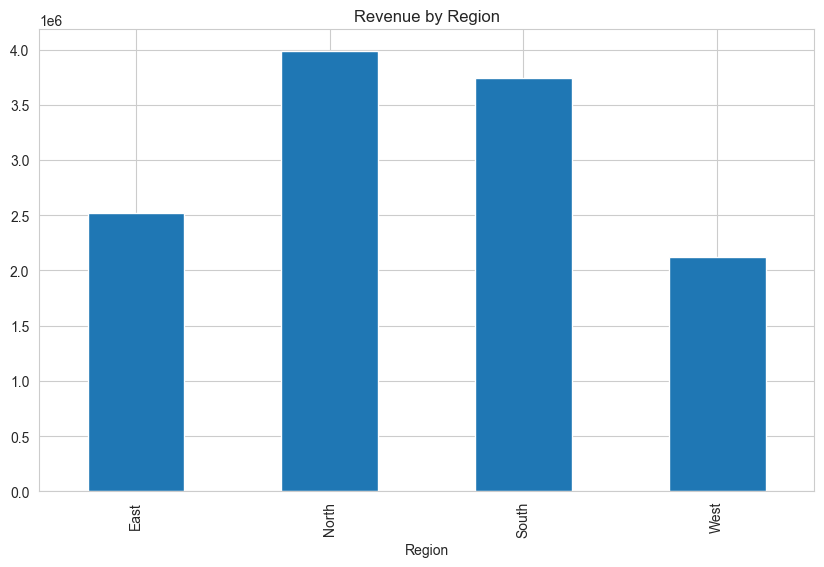

In [44]:
#Revenue by Region 
region_sales.plot(kind = 'bar')
plt.title("Revenue by Region")
plt.show()

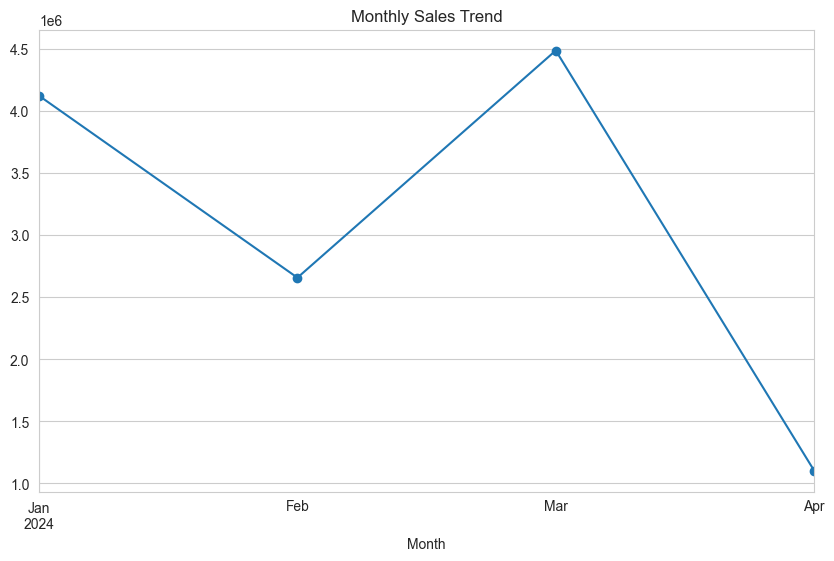

In [45]:
#Monthly Trend
monthly_sales.plot(marker = 'o')
plt.title("Monthly Sales Trend")
plt.show()

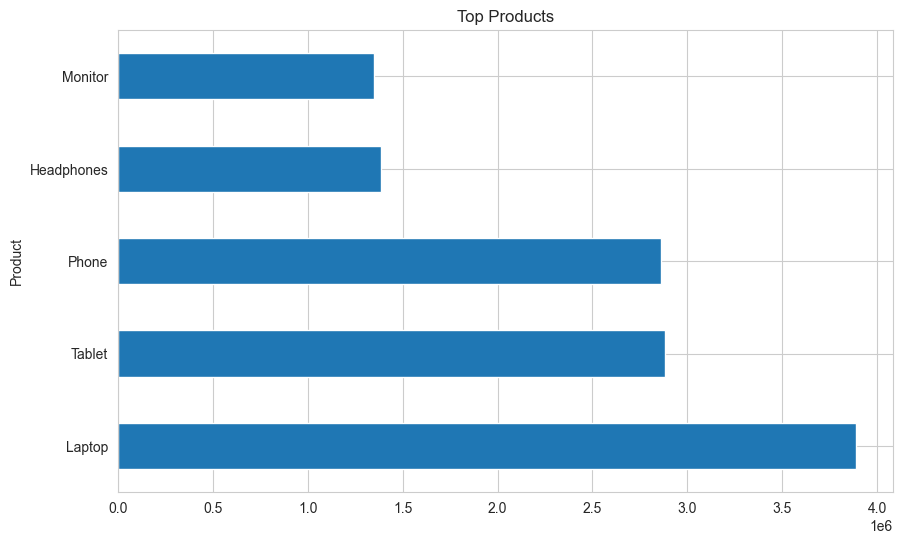

In [46]:
#Top Products (Horizontal bar chart for top 5 products)
product_sales.head(5).plot(kind = 'barh')
plt.title("Top Products")
plt.show()

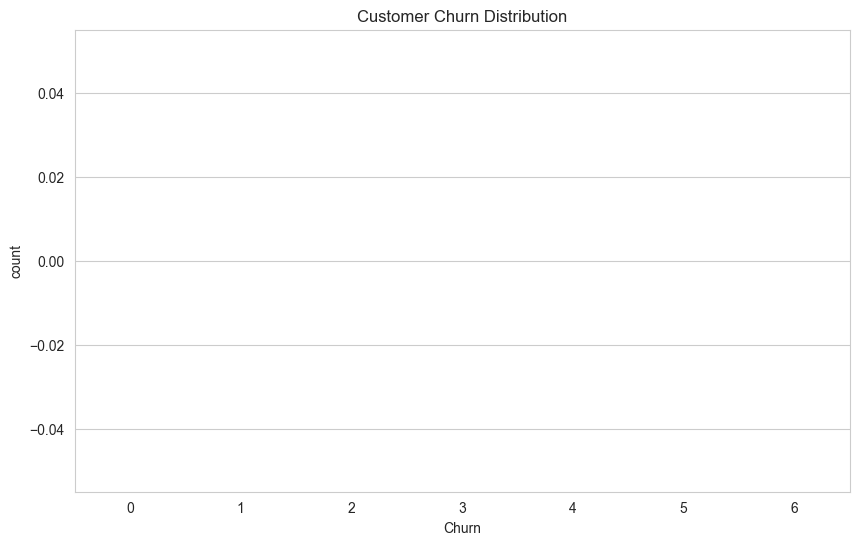

In [47]:
#Churn Distribution
#Count plot for churned vs retained customers
sns.countplot(x = 'Churn', data = df)
plt.title("Customer Churn Distribution")
plt.show()

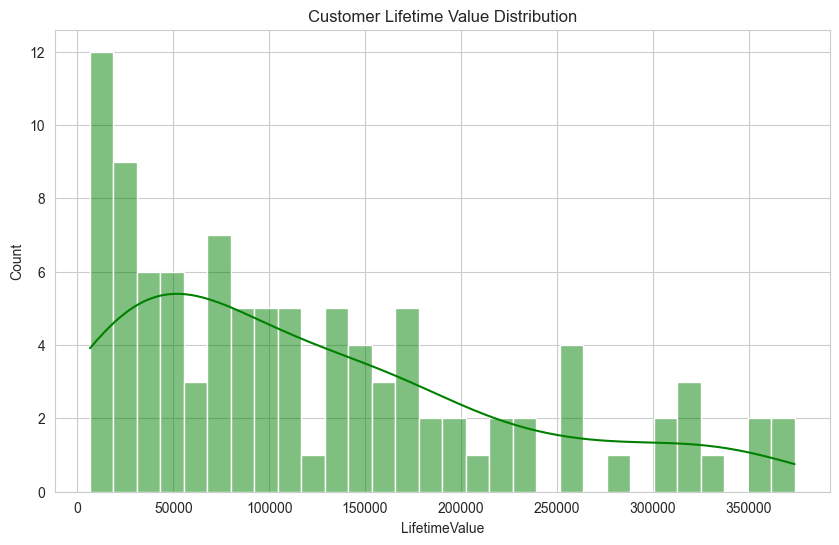

In [48]:
#Customer Lifetime Value
sns.histplot(df['LifetimeValue'], bins = 30, kde=True, color='green')
plt.title("Customer Lifetime Value Distribution")
plt.show()

11.CROSS SELLING (PRODUCTS BOUGHT TOGETHER)

In [49]:
#create customer-product matrix
basket = df.groupby(['Customer_ID', 'Product'])['Quantity'].sum().unstack().fillna(0)

#if a customer bought a product then (1), if not then (0)
#this makes the data suitable for correlation/cross-selling analysis
basket = (basket > 0).astype(int)

basket.corr()  #compute correlation matrix

Product,Headphones,Laptop,Monitor,Phone,Tablet
Product,,,,,
Headphones,1.000000,-0.236067,-0.176471,-0.210042,-0.249004
Laptop,-0.236067,1.000000,-0.236067,-0.280976,-0.333096
Monitor,-0.176471,-0.236067,1.000000,-0.210042,-0.249004
Phone,-0.210042,-0.280976,-0.210042,1.000000,-0.296374
Tablet,-0.249004,-0.333096,-0.249004,-0.296374,1.000000
